In [22]:
from pandas import read_csv
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from matplotlib import pyplot as plt
import seaborn as sb

plt.rcParams["font.family"]="Applegothic"
plt.rcParams["axes.unicode_minus"]=False

In [39]:
iris=load_iris(as_frame=True)
X=iris.data
y=iris.target

target_X=X[['petal length (cm)', 'petal width (cm)']]
target_y=(y==2)

In [24]:
svc_model=SVC(C=1.0,kernel="linear",random_state=1)
total_pipe=make_pipeline(StandardScaler(),svc_model)

<Figure size 640x480 with 0 Axes>

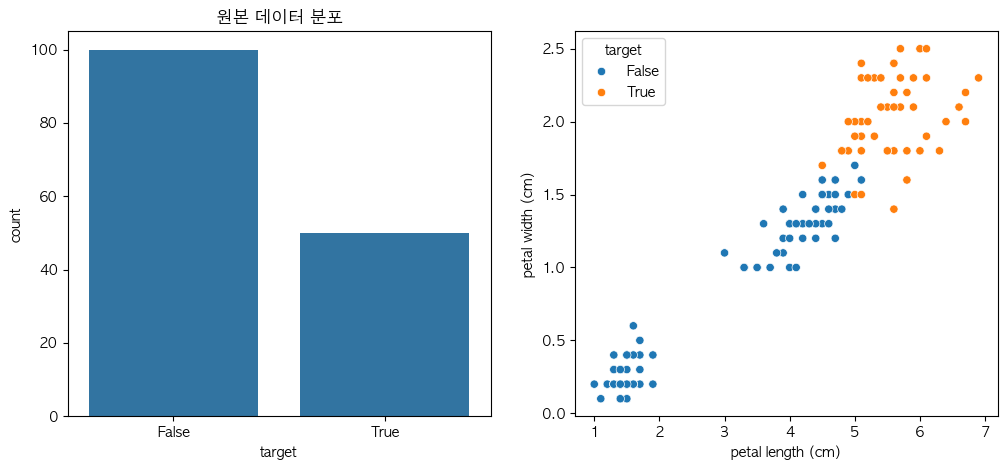

In [42]:
plt.figure()
_,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
a1.set_title("원본 데이터 분포")
sb.countplot(x=target_y,ax=a1)
sb.scatterplot(x=target_X['petal length (cm)'],y=target_X['petal width (cm)'],hue=target_y,ax=a2)
plt.show()
plt.close()

In [4]:
total_pipe

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear', random_state=1))])

모델의 평가를 위해 데이터 셋을 랜덤 분할하겠습니다.

In [50]:
from sklearn.model_selection import StratifiedKFold,train_test_split

In [63]:
train_X,test_X,train_y,test_y=train_test_split(target_X,target_y,test_size=0.2,random_state=1,stratify=target_y)

In [66]:
total_pipe.fit(train_X,train_y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear', random_state=1))])

In [67]:
predict_y=total_pipe.predict(test_X)

In [69]:
from sklearn.metrics import confusion_matrix

In [70]:
confusion_matrix(y_pred=predict_y, y_true=test_y)

array([[20,  0],
       [ 1,  9]])

In [73]:
print('예측값',predict_y[:3])
print('decision_function',total_pipe.decision_function(test_X[:3]))

예측값 [ True False False]
decision_function [ 0.87513732 -1.00004225 -1.37501061]
